In [1]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
#spot perfect (and weak) association

# Cramér’s V: Effect size measure for association between two nominal variables (0 = no association, 1 = perfect association).
# Based on chi-square statistic.

def cramers_v(x, y):
    ct = pd.crosstab(x, y)
    chi2 = chi2_contingency(ct)[0]
    n = ct.sum().sum()
    r, k = ct.shape
    return np.sqrt(chi2 / (n * (min(r, k) - 1)))

df = pd.read_parquet('data/votersurvey_cleaned_noDropNA.parquet')   
target = df['presvote16post_2016']                        #use different target variable
features = df.drop(columns=['presvote16post_2016'])

scores = {}
for col in features.columns:
    try:
        scores[col] = cramers_v(features[col].astype(str), target.astype(str))
    except:
        scores[col] = 0

ranked = pd.Series(scores).sort_values(ascending=False)
print(ranked.head(25))  # Top 20 — anything > 0.7 is suspicious

# Nothing seems to associate to well, exept izip_2016 of course
# But it's interesting that the fealing thermometer's "seem" to be good predictors (let's see...)


/tmp/ipykernel_7592/3632174140.py:11: RuntimeWarning: invalid value encountered in divide
  return np.sqrt(chi2 / (n * (min(r, k) - 1)))


obamaapp_2016                  0.906695
healthreformbill_2016          0.862008
univhealthcov_2016             0.758763
ft_blm_2016                    0.756484
policies_favor_2016            0.750900
imiss_l_2016                   0.744594
envwarm_2016                   0.743679
immi_muslim_2016               0.741031
pid3_2016                      0.740945
pp_primary16_2016              0.737268
ideo5_2016                     0.732197
govt_reg_2016                  0.731580
immi_contribution_2016         0.715517
wealth_2016                    0.707903
gvmt_involment_2016            0.705346
ft_fem_2016                    0.691895
police_threat_2016             0.691821
reverse_discrimination_2016    0.673423
RIGGED_SYSTEM_4_2016           0.655975
affirmact_gen_2016             0.652350
race_slave_2016                0.650431
race_overcome_2016             0.646313
view_transgender_2016          0.646163
RIGGED_SYSTEM_3_2016           0.639734
ft_unions_2016                 0.629128


In [3]:
# define feature sets

top25_cols = ranked.head(25).index.tolist()
top15_cols = ranked.head(15).index.tolist()
top5_cols = ranked.head(5).index.tolist()

df_top25 = df[top25_cols + ["presvote16post_2016"]].dropna() #drop columns that still contain NA's

df_top25.to_csv("data/df_top25_cramersv.csv", index=False)

print(df_top25["presvote16post_2016"].value_counts())

presvote16post_2016
Donald Trump       2912
Hillary Clinton    2863
Name: count, dtype: int64


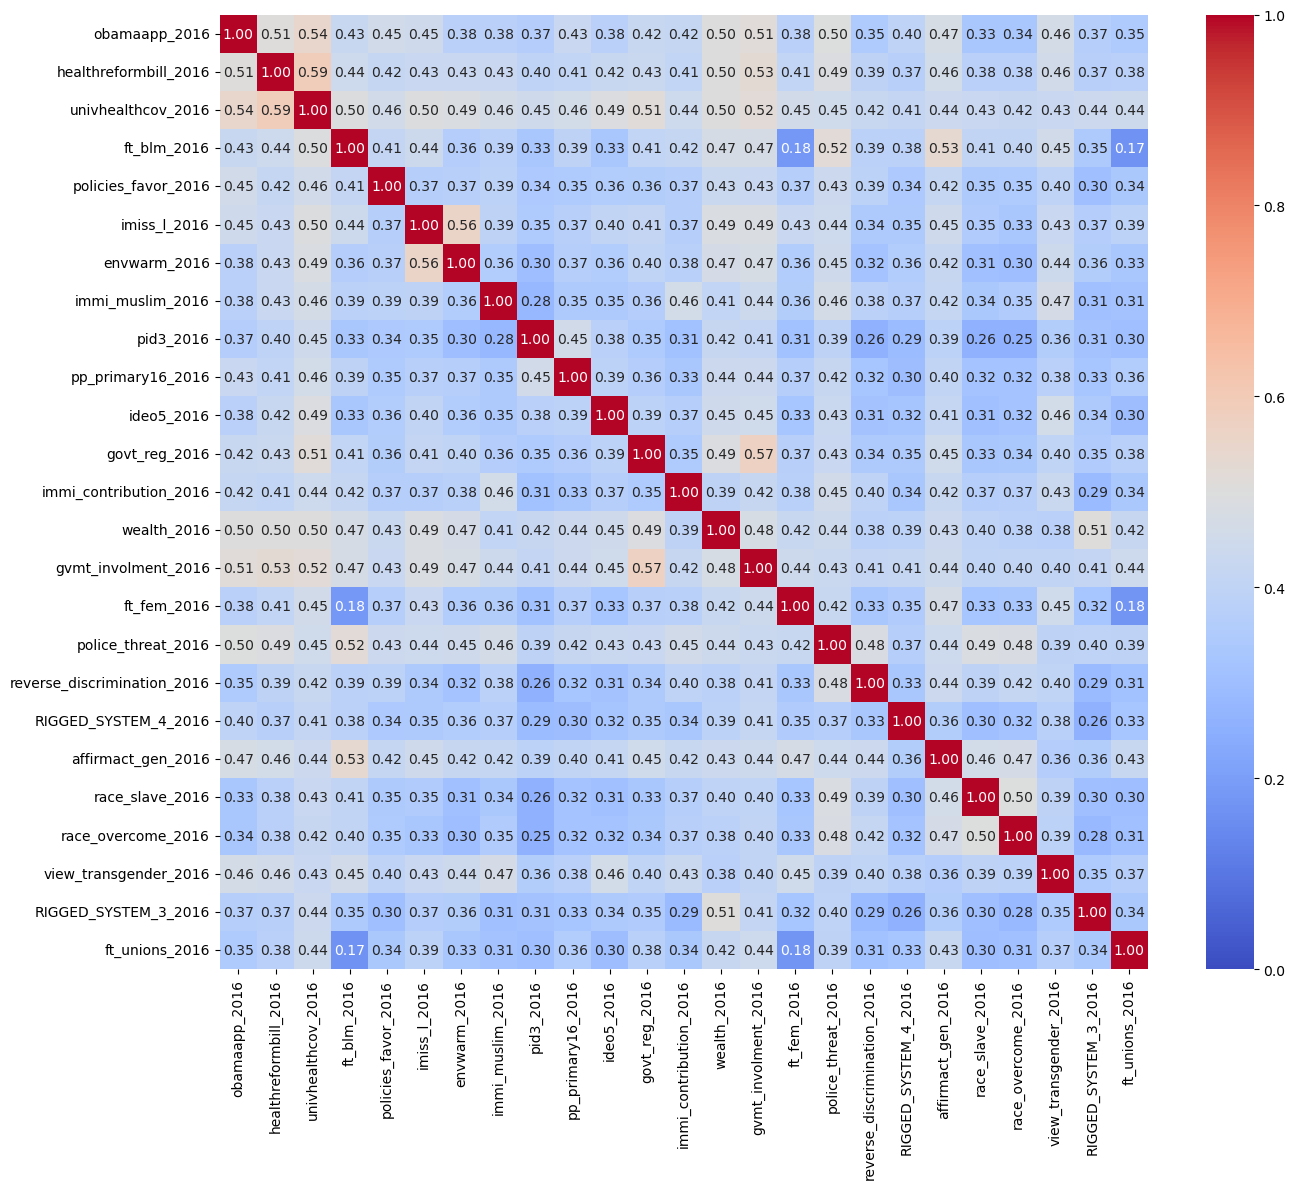

In [4]:
# Here I try to check for collinerity

#Cramers V - heatmap

cramers_matrix = pd.DataFrame(index=top25_cols, columns=top25_cols, dtype=float)
for col1 in top25_cols:
    for col2 in top25_cols:
        try:
            cramers_matrix.loc[col1, col2] = cramers_v(df_top25[col1].astype(str), df_top25[col2].astype(str))
        except:
            cramers_matrix.loc[col1, col2] = 0

plt.figure(figsize=(14, 12))
sns.heatmap(cramers_matrix.astype(float), annot=True, fmt=".2f", cmap="coolwarm", vmin=0, vmax=1)
plt.tight_layout()
plt.show()

# potential collinearity:

# 0.72 strong collinear
# pid7_2016 - pid3_2016

# 0.59 moderate collinearity
# univhealthcov_2016 - healthreformbill_2016

# 0.57 moderate collinearity
# gvmt_involment_2016 - govt_reg_2016

#...

# I would only respect the pid7/3 collinearity : it's basically the same question with different amounts of answer-options
# bcs at some extend survey questions are somehow build up on each other and reflect political opinions

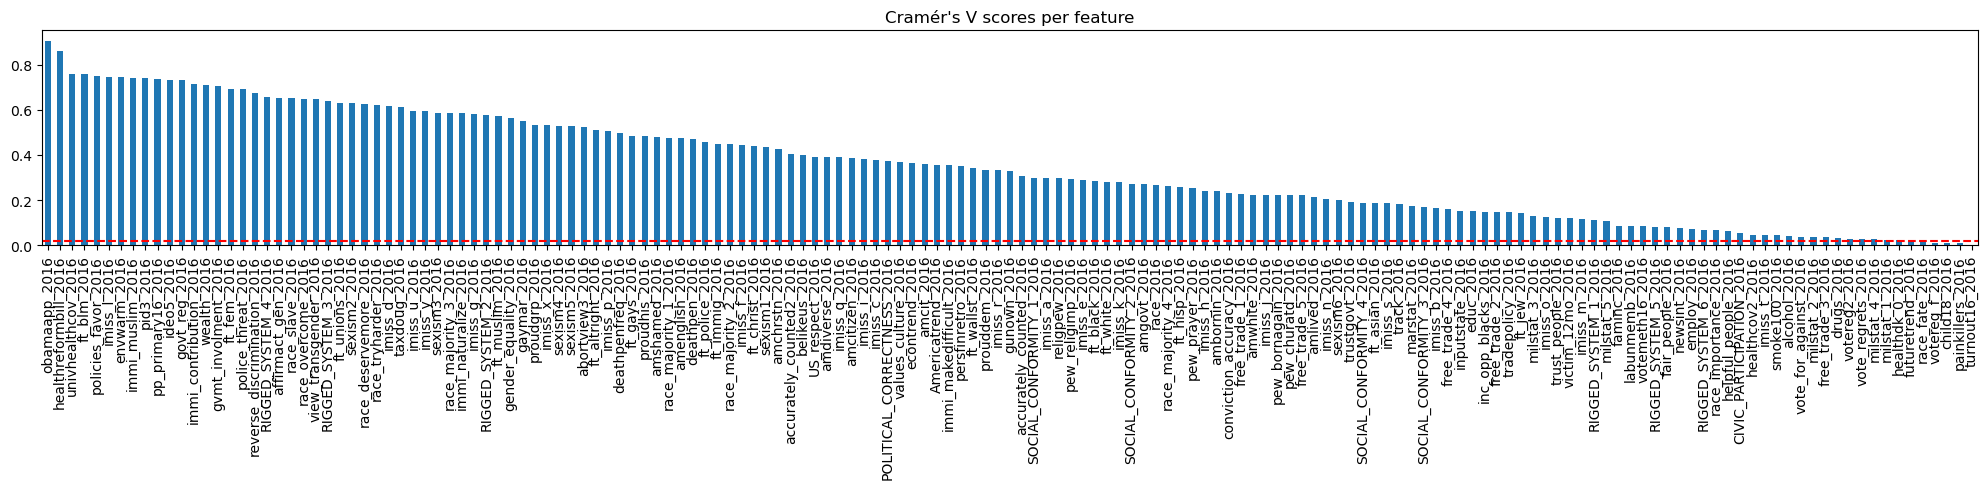

In [5]:
import matplotlib.pyplot as plt

# ellbow method: to decide the threshold to drop columns

ranked.plot(kind='bar', figsize=(20, 5))
plt.axhline(y=0.02, color='red', linestyle='--')
plt.title('Cramér\'s V scores per feature')
plt.tight_layout()
plt.show()

# did not work, gradual increase of feature importance


In [6]:
%pip install lightgbm
%pip install shap

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [8]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
import lightgbm as lgb


# ── 1. Fix dtypes (object → category) ──────
for col in df_top25.select_dtypes(include='object').columns:
    df_top25[col] = df_top25[col].astype('category')

# ── 2. Define target, features and feature ranking ────────────────────
y = (df_top25['presvote16post_2016'] == 'Donald Trump').astype(int)  # Trump=1, Clinton=0
X = df_top25.drop(columns=['presvote16post_2016']) # all columns ecept target feature

# column order of df_top25 already reflects Cramér's V ranking
feature_ranking = X.columns.tolist()

# ── 3. Encode categoricals and split (done once, reused in loop) ──────
cat_cols = X.select_dtypes(include='category').columns.tolist() # find all the categroy columns

enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1) # scikit-learn OrdinalEncoder // unknown ones = -1
X_enc = X.copy()

# fit_transform learns the mapping from X and applies it in one step
X_enc[cat_cols] = enc.fit_transform(X[cat_cols]) # category --> integer

# stratify=y ensures both splits have the same Trump/Clinton ratio
X_train, X_test, y_train, y_test = train_test_split(
    X_enc, y, test_size=0.2, random_state=42, stratify=y # 80/20 split
)

In [11]:
# hyperparameter tuning

from sklearn.model_selection import GridSearchCV

# ── LightGBM hyperparameter tuning ────────────────────────────────────
lgbm_param_grid = {
    'n_estimators':  [100, 300, 500],        # number of trees
    'learning_rate': [0.01, 0.05, 0.1],      # step size per tree
    'max_depth':     [4, 6, 8],              # tree depth
}
lgbm_search = GridSearchCV(
    lgb.LGBMClassifier(random_state=42, verbose=-1),
    lgbm_param_grid,
    cv=5,                                    # 5-fold cross validation
    scoring='roc_auc',                       # optimize for AUC
    n_jobs=1                                # use all CPU cores
)
lgbm_search.fit(X_train, y_train)
print("Best LGBM params:", lgbm_search.best_params_)
print("Best LGBM AUC:  ", round(lgbm_search.best_score_, 4))

# ── Logistic Regression hyperparameter tuning ─────────────────────────
scaler = StandardScaler()

lr_param_grid = {
    'C': [0.0001, 0.001, 0.01, 0.1, 1],  # regularization strength — smaller = stronger regularization 
}
lr_search = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42),
    lr_param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=1
)
lr_search.fit(scaler.fit_transform(X_train), y_train)
print("Best LR params:", lr_search.best_params_)
print("Best LR AUC:   ", round(lr_search.best_score_, 4))

Best LGBM params: {'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 100}
Best LGBM AUC:   0.994
Best LR params: {'C': 0.01}
Best LR AUC:    0.9902


In [7]:
#Hyperparameter tuning: 
# lgbm: simplest settings won
# LR:   C = 0.01
# C = how sceptical model is towards training data (train-trust-factor) --> adds a penalty to the loss function

# ── 4. Loop: add one feature at a time, fit both models ───────────────
results = []

for n in range(1, len(feature_ranking) + 1):
    top_n = feature_ranking[:n] #select first n features

    X_train_n = X_train[top_n] # define training subset
    X_test_n  = X_test[top_n] # define testing subset

    # Logistic Regression (requires scaling)
    scaler = StandardScaler() #define scaler
    lr = LogisticRegression(max_iter=1000, random_state=42, C=0.01) # max_iter=1000 is enough for the solver to find the solution
    lr.fit(scaler.fit_transform(X_train_n), y_train) #scalling and fitting
    auc_lr = roc_auc_score(y_test, lr.predict_proba(scaler.transform(X_test_n))[:, 1]) # test AUC

    # LightGBM (no scaling needed)
    lgbm = lgb.LGBMClassifier(n_estimators=500, learning_rate=0.05,
                               max_depth=6, random_state=42, verbose=-1) #verbose=-1 --> only show the clean print
    lgbm.fit(X_train_n, y_train, # fit the LigthGBM model
             eval_set=[(X_test_n, y_test)], # # eval_set: for monitoring test performance
             callbacks=[lgb.early_stopping(50, verbose=False)]) #stop if not getting better for 50 rounds
    auc_lgbm = roc_auc_score(y_test, lgbm.predict_proba(X_test_n)[:, 1]) # test AUC

    results.append({
        'n_features':      n, #how many features used
        'added_feature':   top_n[n - 1], # which feature was added
        'auc_lr_train':    round(roc_auc_score(y_train, lr.predict_proba(scaler.transform(X_train_n))[:, 1]), 4), #train AUC for LR
        'auc_lr_test':     round(auc_lr,   4), #test AUC for LR
        'auc_lgbm_train':  round(roc_auc_score(y_train, lgbm.predict_proba(X_train_n)[:, 1]), 4), #train AUC for lgbm
        'auc_lgbm_test':   round(auc_lgbm, 4) #test AUC for lgbm
    })
    print(f"n={n:2d} | LR: {auc_lr:.4f} | LGBM: {auc_lgbm:.4f} | added: {top_n[n-1]}") #formating code

results_df = pd.DataFrame(results) # one row per feature set

n= 1 | LR: 0.8910 | LGBM: 0.9777 | added: obamaapp_2016
n= 2 | LR: 0.9198 | LGBM: 0.9911 | added: healthreformbill_2016
n= 3 | LR: 0.9449 | LGBM: 0.9916 | added: univhealthcov_2016
n= 4 | LR: 0.9670 | LGBM: 0.9912 | added: ft_blm_2016
n= 5 | LR: 0.9755 | LGBM: 0.9923 | added: policies_favor_2016
n= 6 | LR: 0.9772 | LGBM: 0.9922 | added: imiss_l_2016
n= 7 | LR: 0.9808 | LGBM: 0.9917 | added: envwarm_2016
n= 8 | LR: 0.9821 | LGBM: 0.9925 | added: immi_muslim_2016
n= 9 | LR: 0.9886 | LGBM: 0.9940 | added: pid3_2016
n=10 | LR: 0.9887 | LGBM: 0.9942 | added: pp_primary16_2016
n=11 | LR: 0.9891 | LGBM: 0.9951 | added: ideo5_2016
n=12 | LR: 0.9897 | LGBM: 0.9953 | added: govt_reg_2016
n=13 | LR: 0.9900 | LGBM: 0.9957 | added: immi_contribution_2016
n=14 | LR: 0.9905 | LGBM: 0.9959 | added: wealth_2016
n=15 | LR: 0.9906 | LGBM: 0.9958 | added: gvmt_involment_2016
n=16 | LR: 0.9922 | LGBM: 0.9959 | added: ft_fem_2016
n=17 | LR: 0.9921 | LGBM: 0.9958 | added: police_threat_2016
n=18 | LR: 0.9926

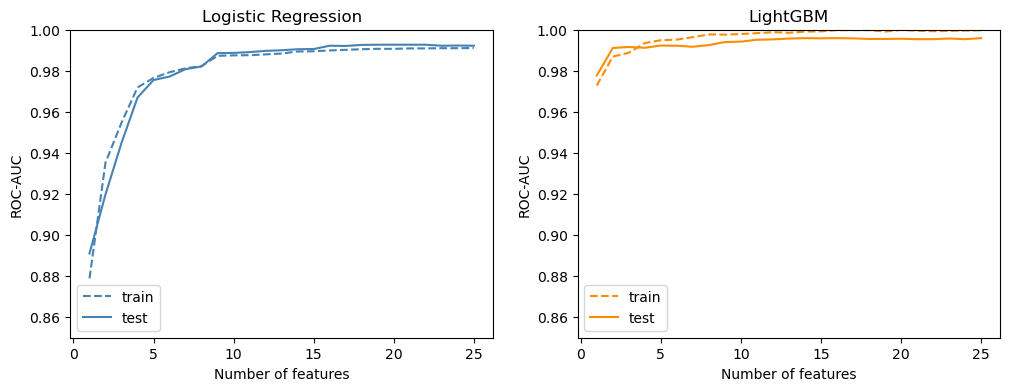

In [12]:
# ── plots ───────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4)) #side by side formating

# dashed line = train, solid line= test
# big cap --> overfitting

ax1.plot(results_df['n_features'], results_df['auc_lr_train'], color='steelblue', linestyle='--', label='train')
ax1.plot(results_df['n_features'], results_df['auc_lr_test'],  color='steelblue', linestyle='-',  label='test')
ax1.set_title('Logistic Regression')
ax1.set_xlabel('Number of features')
ax1.set_ylabel('ROC-AUC')
ax1.set_ylim(0.85, 1.0) #zoom in to get the differences
ax1.legend()

ax2.plot(results_df['n_features'], results_df['auc_lgbm_train'], color='darkorange', linestyle='--', label='train')
ax2.plot(results_df['n_features'], results_df['auc_lgbm_test'],  color='darkorange', linestyle='-',  label='test')
ax2.set_title('LightGBM')
ax2.set_xlabel('Number of features')
ax2.set_ylabel('ROC-AUC')
ax2.set_ylim(0.85, 1.0) #zoom in to get the differences (same scale)
ax2.legend()

plt.tight_layout

plt.savefig("my_plot.png")
plt.show()

In [ ]:
import shap

# Explanation regarding SHAP values
# SHAP tells us how strongly a feature influenced the prediction (mean shap) and 
# in which direction ((+) Trump / (-)Clinton).  
# the higher the shap value is, the more that feature consistently moved predictions, regardless of direction.

# ── 1. Refit LightGBM on all 25 features for SHAP ──────────────────── #same logic as before

lgbm_final = lgb.LGBMClassifier(n_estimators=500, learning_rate=0.05,
                                 max_depth=6, random_state=42, verbose=-1) #same configuration as before
lgbm_final.fit(X_train, y_train,
               eval_set=[(X_test, y_test)],
               callbacks=[lgb.early_stopping(50, verbose=False)])

# ── 2. Compute SHAP values on test set ───────────────────────────────

# Create an "interpreter"; catches decisions of lgbm
# which specific answers were the "decisive factors" for each prediction.
explainer = shap.TreeExplainer(lgbm_final) 

# execution of the interpreter: finds the tipping points
shap_vals  = explainer.shap_values(X_test)  # positive = pushes toward Trump

# ── 3. Beeswarm plot (uses encoded X_test but shows feature names) ────

shap.summary_plot(shap_vals, X_test, plot_type="dot") # 1dot per person per feature // color off because numbers are jsut encoded...

# ── 4. Interpretable summary: feature + raw answer label ──────────────
summary_rows = []

for feat in feature_ranking: # goes through all features in the CramersV-ranking order

    # get the SHAP values for this one feature (one value per person)
    feat_idx = X_test.columns.tolist().index(feat)  # column index of this feature
    shap_col = shap_vals[:, feat_idx]               # calculate SHAP values; in a Matrix

    # focus only on rows where this feature had a strong impact
    strong_impact = np.abs(shap_col) >= np.percentile(np.abs(shap_col), 80)  # True/False mask, top 20% rows(people)

    # get the original (pre-encoding) survey answers for those rows
    strong_answers = X.loc[X_test.index[strong_impact], feat]  # e.g. ["Strongly Disapprove", "Approve", ...]
    strong_shap    = shap_col[strong_impact]                    # their corresponding SHAP values

    # split by direction: positive SHAP = toward Trump, negative = toward Clinton
    trump_answers   = strong_answers[strong_shap > 0]  # e.g. ["Strongly Disapprove", ...]
    clinton_answers = strong_answers[strong_shap < 0]  # e.g. ["Strongly Approve", ...]

    summary_rows.append({
        'feature':          feat, # the feature 
        'mean_abs_shap':    round(np.abs(shap_col).mean(), 4),   # mean prediction impact across all people (takses all shap values for this feature across every person in the test set)
        'answer_→_Trump':   trump_answers.mode()[0]   if len(trump_answers)   > 0 else '—',  # most common answer among Trump-pushed rows
        'answer_→_Clinton': clinton_answers.mode()[0] if len(clinton_answers) > 0 else '—',  # most common answer among Clinton-pushed rows
    })

summary_df = pd.DataFrame(summary_rows)

for _, row in summary_df.iterrows(): # print all the features, shap value, triggerquestion-trump, trigger-question-clinton
    print(f"""
Feature:          {row['feature']}
Mean |SHAP|:      {row['mean_abs_shap']}
→ Trump:          {row['answer_→_Trump']}
→ Clinton:        {row['answer_→_Clinton']}
{'-'*60}""")